<a href="https://colab.research.google.com/github/scottspurlock/csc4466-s2026/blob/main/demos/day14_homography_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision
## Day 14 Homography Example

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


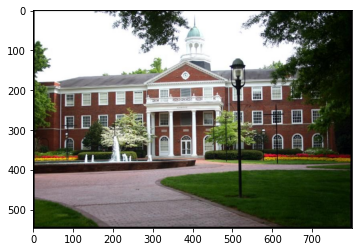

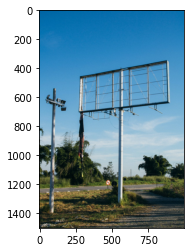

In [ ]:
img1 = cv2.imread('alamance.jpg')
plt.imshow(img1[:,:,::-1])
plt.show()

img2 = cv2.imread('billboard.jpg')
plt.imshow(img2[:,:,::-1])
plt.show()


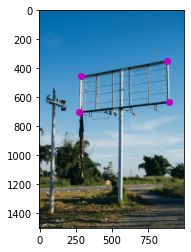

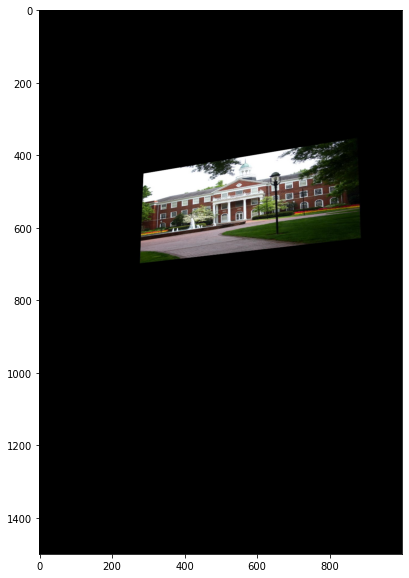

In [ ]:
# Four corners from first image
h, w = img1.shape[:2]
pts_src = np.array([[0, 0], [w, 0], [w, h],[0, h]])

# Four corners from second image
pts_dst = np.array([[285, 450],[880, 350],[890, 630],[275, 700]])

# Calculate Homography
H, status = cv2.findHomography(pts_src, pts_dst)

# Warp first image to destination based on homography
h, w = img2.shape[:2]
img3 = cv2.warpPerspective(img1, H, (w, h))

plt.imshow(img2[:,:,::-1])
plt.plot(pts_dst[:, 0], pts_dst[:, 1], 'mo')
plt.show()

# Display images
plt.figure(figsize=(10,10))
plt.imshow(img3[:,:,::-1]);


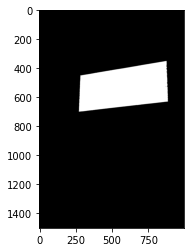

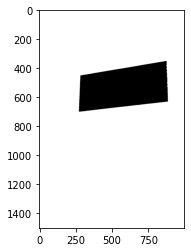

In [ ]:
mask = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY) > 0
bgmask = ~mask
mask = mask.astype('uint8') * 255
bgmask = bgmask.astype('uint8') * 255
plt.imshow(mask, cmap='gray')
plt.show()
plt.imshow(bgmask, cmap='gray');

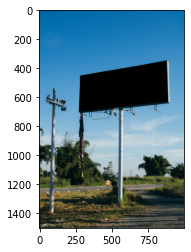

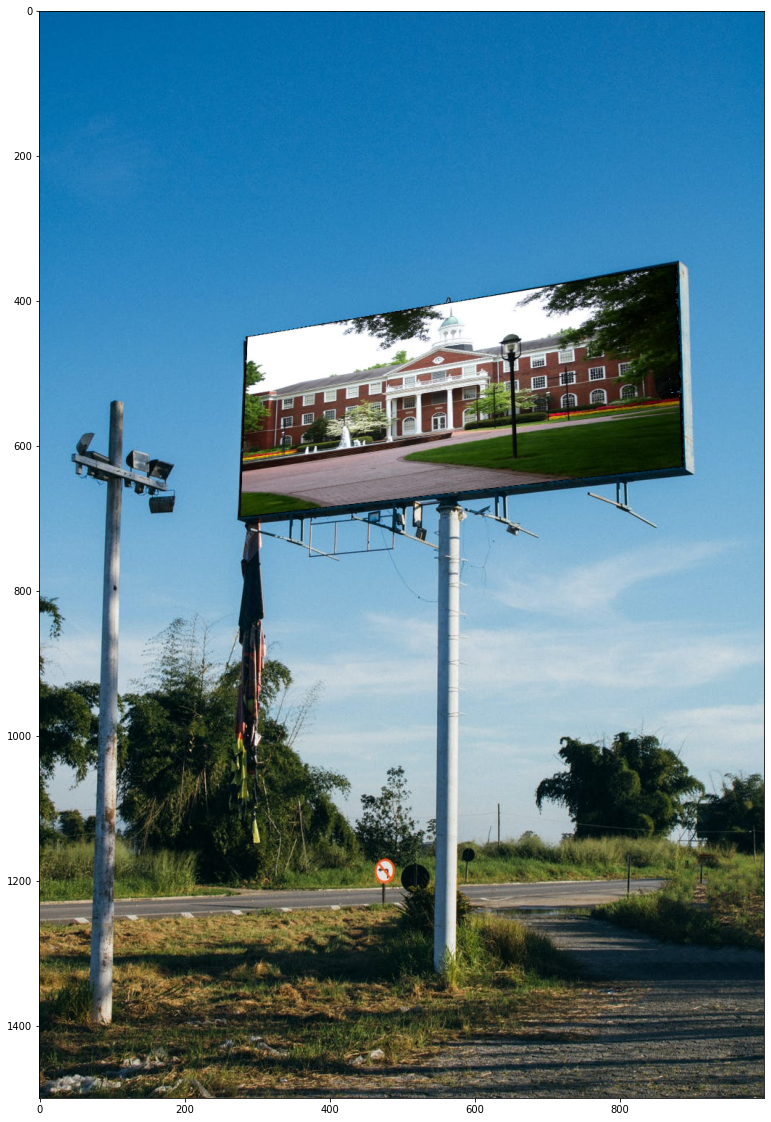

In [ ]:
img4 = cv2.bitwise_or(img2, img2, None, mask=bgmask)
plt.imshow(img4[:,:,::-1])
plt.show()

plt.figure(figsize=(20,20))
img5 = cv2.bitwise_or(img4, img3)
plt.imshow(img5[:,:,::-1])
plt.show();